# Comparing Three Online HMM Methods

This notebook compares three online methods for parameter estimation in Gaussian HMMs:
1. **Online EM** (Cappé 2009) - Stochastic EM with exponential moving averages
2. **Streaming HMM** - Particle filtering with beam search
3. **RBPF** - Rao-Blackwellised Particle Filter with ESS-based resampling

All methods estimate regime means online from streaming observations. We evaluate:
- Parameter convergence (means across regimes)
- Computational efficiency
- Algorithm characteristics

**Data:** Synthetic 3-regime Gaussian HMM with known transition probabilities.



In [25]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from streaming_hmm import run_streaming_hmm
from rbpf_hmm import run_rbpf_streaming_hmm

In [26]:
# Configure matplotlib
%config InlineBackend.figure_format = "retina"
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["figure.figsize"] = (7, 3.0)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

sns.set_palette("colorblind")

## Section 1: Load and Prepare Synthetic Data

Generate synthetic time series from a 3-regime Gaussian HMM with:
- Known transition matrix (high self-transition probability = 0.99)
- Known regime means: [-2, 0, 2]
- Observation variance: 1.0


In [27]:
# Initialize random key
key = jax.random.PRNGKey(42)
key_sample, key_gauss, key_stream, key_em = jax.random.split(key, 4)

# Define HMM parameters (known)
n_regimes = 3
transition_matrix_diag = jnp.ones(n_regimes) * 0.99
transition_matrix = jnp.ones((n_regimes, n_regimes)) * (1 - transition_matrix_diag) / (n_regimes - 1)
transition_matrix = transition_matrix.at[jnp.diag_indices(n_regimes)].set(transition_matrix_diag)
log_transition_matrix = jnp.log(transition_matrix)

true_means = jnp.array([-2.0, 0.0, 2.0])
obs_var_true = 1.0 ** 2
print("True parameters:")
print(f"  Means: {true_means}")
print(f"  Variance: {obs_var_true}")
print(f"  Transition matrix diagonal (self-transition): {transition_matrix_diag[0]}")


True parameters:
  Means: [-2.  0.  2.]
  Variance: 1.0
  Transition matrix diagonal (self-transition): 0.9900000095367432


In [28]:
# Data generation function
def step_hmm(state, key):
    """One step of Markov chain with Gaussian observation."""
    key_state, key_noise = jax.random.split(key)
    proba_change = transition_matrix[state]
    state_next = jax.random.choice(key_state, n_regimes, p=proba_change)
    err = jax.random.normal(key_noise) * jnp.sqrt(obs_var_true)
    obs = true_means[state_next] + err
    return state_next, (state_next, obs)

# Generate observations
state_init = 0
n_steps = 2000

keys = jax.random.split(key_sample, n_steps)
_, (true_states, observations) = jax.lax.scan(step_hmm, state_init, keys)

print(f"\nGenerated data:")
print(f"  Length: {n_steps} observations")
print(f"  Observations range: [{observations.min():.2f}, {observations.max():.2f}]")
print(f"  True regime counts: {np.array(np.bincount(np.array(true_states)))}")



Generated data:
  Length: 2000 observations
  Observations range: [-4.74, 4.77]
  True regime counts: [575 690 735]


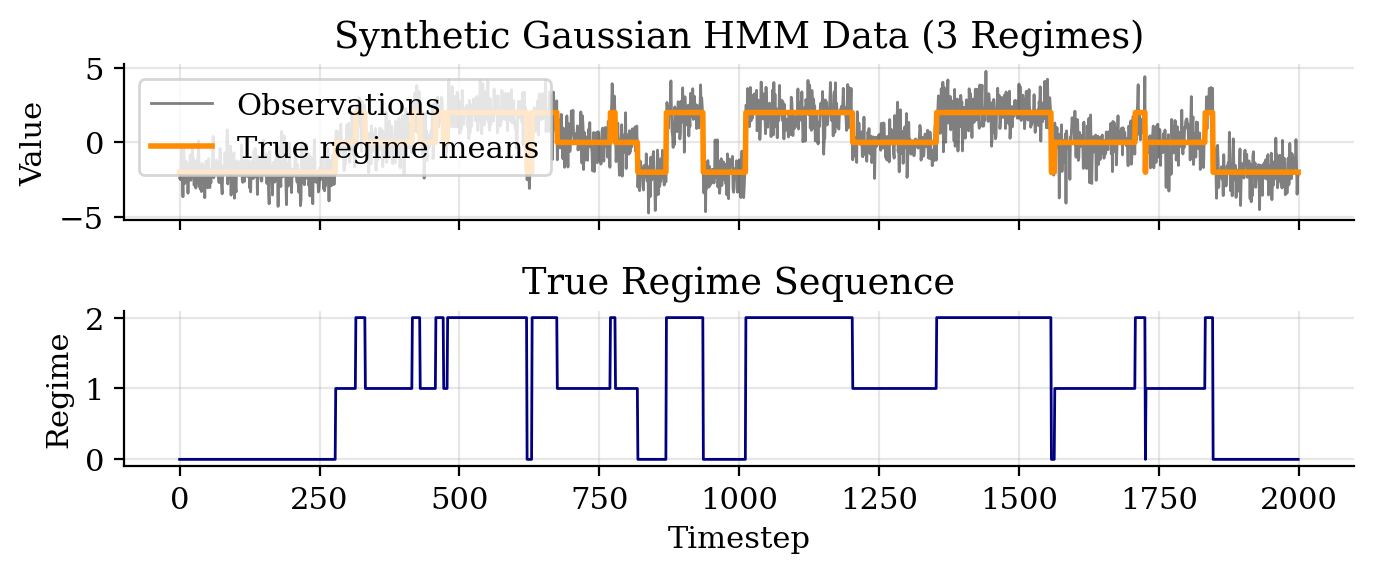

In [29]:
# Visualize generated data
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# Plot observations and true means
ax1.plot(observations, c="black", alpha=0.5, linewidth=1, label="Observations")
ax1.plot(true_means[true_states], c="darkorange", linewidth=2, label="True regime means")
# ax1.set_xlabel("Time step")
ax1.set_ylabel("Value")
ax1.set_title("Synthetic Gaussian HMM Data (3 Regimes)")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot regime sequence
ax2.plot(true_states, c="navy", linewidth=1)
ax2.set_xlabel("Timestep")
ax2.set_ylabel("Regime")
ax2.set_yticks([0, 1, 2])
ax2.set_title("True Regime Sequence")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [30]:
import numpy as np
from scipy.stats import norm

def online_em_gaussian(
    y,                  # numpy array of observations (T,)
    transition_matrix,  # (K,K) known transition probabilities
    sigma2,             # known observation variance
    alpha=0.6,           # step-size exponent (0.5 < alpha <= 1),
    seed=314
):
    """
    Online EM for Gaussian HMM with known variance.
    Estimates regime means only.
    """
    np.random.seed(seed)

    T = len(y)
    K = transition_matrix.shape[0]

    # ---- Initialisation ----
    mu = np.random.randn(K)              # regime means
    phi = np.ones(K) / K                 # filtering distribution
    N_hat = np.zeros(K)                  # expected counts
    S_hat = np.zeros(K)                  # expected weighted sums

    mu_history = np.zeros((T, K))

    for t in range(T):

        gamma = (t + 1) ** (-alpha)

        # ---- Filtering step ----
        # Predict
        pred = phi @ transition_matrix   # (K,)

        # Emission likelihood
        likelihood = norm.pdf(y[t], mu, np.sqrt(sigma2))

        # Update
        phi = pred * likelihood
        phi = phi / np.sum(phi)

        # ---- Online sufficient statistics ----
        N_hat = (1 - gamma) * N_hat + gamma * phi
        S_hat = (1 - gamma) * S_hat + gamma * phi * y[t]

        # ---- M-step ----
        mu = S_hat / (N_hat + 1e-12)

        mu_history[t] = mu

    return mu, mu_history

In [31]:
alpha = 0.1
mu_final, hist_means_em = online_em_gaussian(observations, transition_matrix, obs_var_true)

## Section 2: Streaming HMM Implementation

Run the **Streaming HMM** algorithm which uses particle filtering with beam search.

**Algorithm:** Maintains particles tracking regime paths and parameters, updates with each observation, and keeps top-K particles by weight.


In [32]:
# Run Streaming HMM with better initialization
bel_final, (hist_lw, hist_means, hist_var, hist_forecast), hist_weights = run_streaming_hmm(
    observations,
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    key=key_stream,
    n_particles=10,
    var_obs=obs_var_true,
    # Let it initialize automatically
)

In [33]:
hist_means_pred = jnp.einsum("ts,tsk...->tk", hist_weights, hist_means)

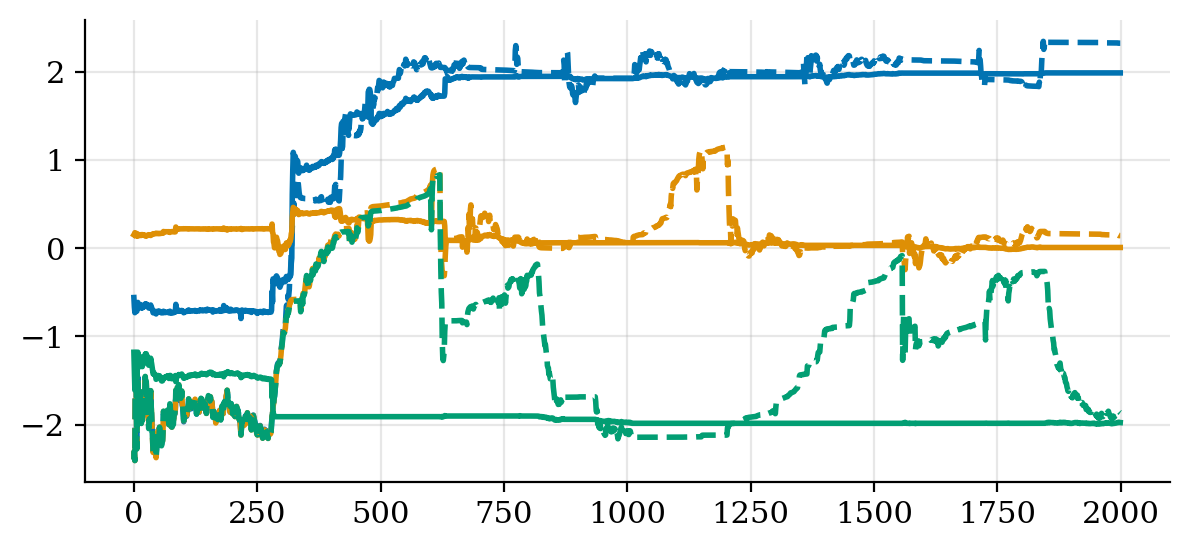

In [34]:
colors = sns.color_palette()

for i in range(n_regimes):
    plt.plot(hist_means_em[:, i], c=colors[i], linewidth=2, linestyle="--")
    plt.plot(hist_means_pred[:, i], c=colors[i], linewidth=2)
plt.grid(alpha=0.3)

## Section 3: Rao-Blackwellised Particle Filter (RBPF) Implementation

Run the **RBPF** algorithm which combines regime sampling with Rao-Blackwellisation.

**Algorithm:** Each particle tracks a regime sequence. At each step: (1) sample the next regime from the transition matrix, (2) update parameters, (3) resample particles when ESS drops below threshold.



In [36]:
# Run RBPF with 100 particles and ESS-based resampling
key_rbpf = jax.random.split(key_em, 1)[0]
bel_rbpf, (hist_lw_rbpf, hist_means_rbpf, hist_forecast_rbpf, hist_ess), hist_weights_rbpf = run_rbpf_streaming_hmm(
    observations,
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    key=key_rbpf,
    n_particles=10,
    var_obs=obs_var_true,
    ess_threshold=0.5,
)


In [37]:
# Compute mean predictions for RBPF (already Rao-Blackwellised)
hist_means_rbpf_regimes = hist_means_rbpf  # Shape: (T, K)

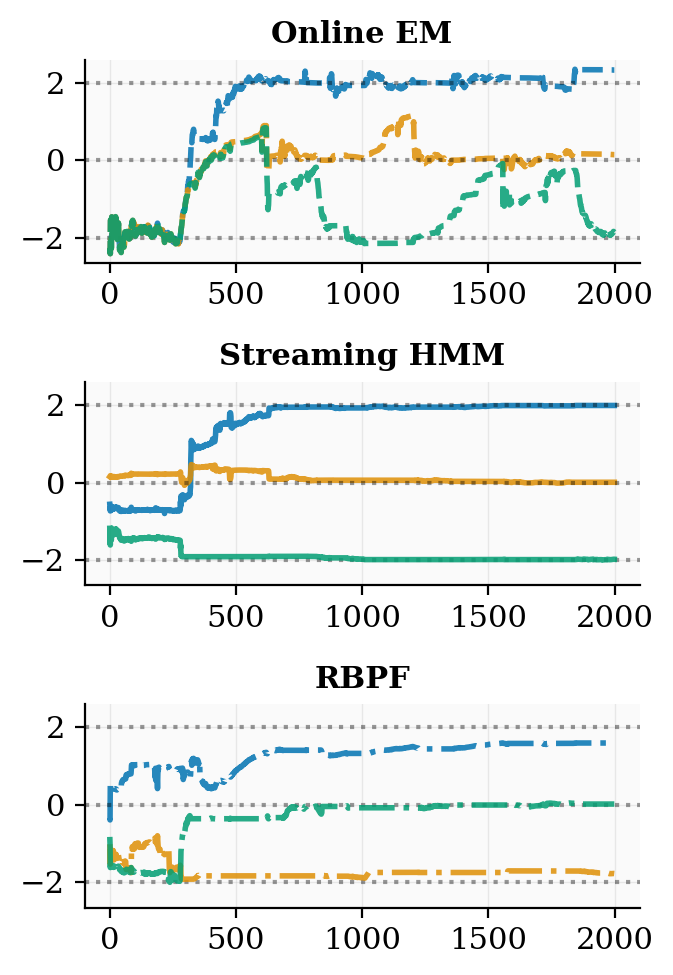

In [38]:
# Comparison plot: All three methods side-by-side
figsize=(3.5, 2.5 * 2)
fig, axes = plt.subplots(3, 1, figsize=figsize, sharey=True)

# Define line styles and markers for visual distinction
methods = [
    ("Online EM", hist_means_em, "--"),
    ("Streaming HMM", hist_means_pred, "-"),
    ("RBPF", hist_means_rbpf_regimes, "-."),
]

# True means as reference
true_mean_lines = [true_means[i] for i in range(n_regimes)]

for ax_idx, (ax, (method_name, means_data, linestyle)) in enumerate(zip(axes, methods)):
    # Plot estimated means for each regime
    for regime_idx in range(n_regimes):
        ax.plot(
            means_data[:, regime_idx],
            label=f"Regime {regime_idx+1}",
            linestyle=linestyle,
            linewidth=2.0,
            color=colors[regime_idx],
            alpha=0.85,
        )
        # Add true mean as dashed reference line
        ax.axhline(
            y=true_means[regime_idx],
            color="black",
            linestyle=":",
            linewidth=1.5,
            alpha=0.4,
        )
    
    # ax.set_xlabel("Time step", fontsize=10)
    # if ax_idx == 0:
    #     ax.set_ylabel("Mean estimate", fontsize=10)
    ax.set_title(method_name, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.25, linestyle="-", linewidth=0.5)
    ax.set_facecolor("#fafafa")
    # if ax_idx == 0:
    #     ax.legend(loc="best", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()


In [39]:
# Modified Online EM with one-step-ahead predictions
def online_em_gaussian_with_predictions(
    y,                  
    transition_matrix,  
    sigma2,             
    alpha=0.6,
    seed=314
):
    """
    Online EM for Gaussian HMM with predictions.
    Returns regime means history and one-step-ahead predictions.
    """
    np.random.seed(seed)

    T = len(y)
    K = transition_matrix.shape[0]

    mu = np.random.randn(K)
    phi = np.ones(K) / K
    N_hat = np.zeros(K)
    S_hat = np.zeros(K)

    mu_history = np.zeros((T, K))
    predictions = np.zeros(T)  # One-step-ahead predictions

    for t in range(T):
        gamma = (t + 1) ** (-alpha)

        # Predict next observation BEFORE seeing y[t]
        pred_mean = phi @ mu  # Expected value under current regime distribution
        predictions[t] = pred_mean

        # Filtering step
        pred = phi @ transition_matrix
        likelihood = norm.pdf(y[t], mu, np.sqrt(sigma2))
        phi = pred * likelihood
        phi = phi / (np.sum(phi) + 1e-12)

        # Update sufficient statistics
        N_hat = (1 - gamma) * N_hat + gamma * phi
        S_hat = (1 - gamma) * S_hat + gamma * phi * y[t]
        mu = S_hat / (N_hat + 1e-12)

        mu_history[t] = mu

    return mu, mu_history, predictions

# Run modified Online EM
alpha = 0.1
mu_final_em, hist_means_em, osa_pred_em = online_em_gaussian_with_predictions(
    np.array(observations), 
    np.array(transition_matrix), 
    obs_var_true,
    alpha=alpha
)


In [40]:
# Extract one-step-ahead predictions
# Streaming HMM: already has forecast from hist_forecast
osa_pred_streaming_hmm = hist_forecast["mean"]

# RBPF: hist_forecast_rbpf contains scalar one-step-ahead forecasts (T,)
# accounting for regime transitions via einsum with transition matrix
osa_pred_rbpf = np.array(hist_forecast_rbpf).flatten()

print(f"OSA Predictions computed:")
print(f"  Online EM shape: {osa_pred_em.shape}")
print(f"  Streaming HMM shape: {np.array(osa_pred_streaming_hmm).shape}")
print(f"  RBPF shape: {osa_pred_rbpf.shape}")


OSA Predictions computed:
  Online EM shape: (2000,)
  Streaming HMM shape: (2000,)
  RBPF shape: (2000,)


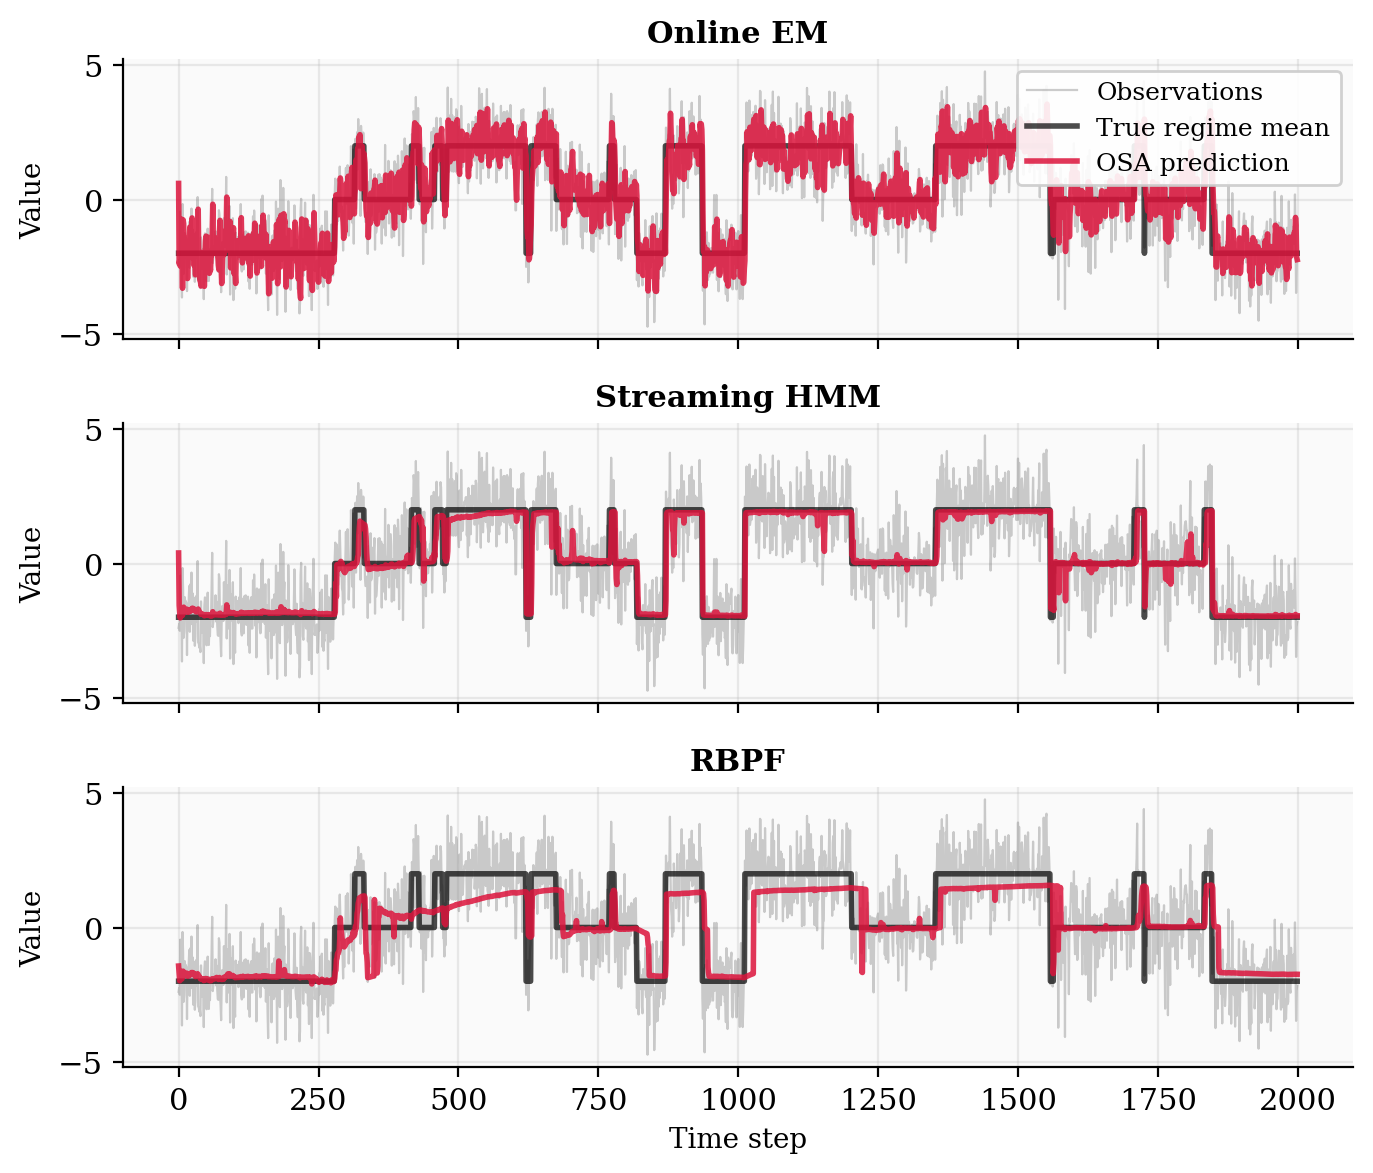

In [41]:
# Comparison plot: One-step-ahead predictions
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

time_range = np.arange(n_steps)
method_names = ["Online EM", "Streaming HMM", "RBPF"]
predictions = [osa_pred_em, osa_pred_streaming_hmm, osa_pred_rbpf]

for ax_idx, (ax, method_name, pred) in enumerate(zip(axes, method_names, predictions)):
    # Plot observations
    ax.plot(time_range, observations, c="gray", alpha=0.4, linewidth=0.8, label="Observations")
    
    # Plot true means
    ax.plot(time_range, true_means[true_states], c="black", 
            linewidth=2, label="True regime mean", alpha=0.7)
    
    # Plot predictions
    ax.plot(time_range, pred, c="crimson", linewidth=2, 
            label="OSA prediction", alpha=0.85)
    
    ax.set_title(method_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Value", fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_facecolor("#fafafa")
    
    if ax_idx == 0:
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

axes[-1].set_xlabel("Time step", fontsize=10)
plt.tight_layout()
plt.show()


In [42]:
# Compute predictive metrics
true_observations = np.array(observations)

# Prediction errors
errors_em = true_observations - osa_pred_em
errors_streaming = true_observations - np.array(osa_pred_streaming_hmm)
errors_rbpf = true_observations - osa_pred_rbpf

# Metrics
def compute_metrics(errors, name):
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    mape = np.mean(np.abs(errors / (np.abs(true_observations) + 1e-6))) * 100
    cumulative_error = np.cumsum(np.abs(errors))
    
    return {
        "name": name,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "cumulative_error": cumulative_error,
        "errors": errors
    }

metrics = [
    compute_metrics(errors_em, "Online EM"),
    compute_metrics(errors_streaming, "Streaming HMM"),
    compute_metrics(errors_rbpf, "RBPF"),
]

# Print performance summary
print("=" * 70)
print("ONE-STEP-AHEAD PREDICTION PERFORMANCE")
print("=" * 70)
for m in metrics:
    print(f"\n{m['name']}:")
    print(f"  Mean Absolute Error (MAE):     {m['mae']:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {m['rmse']:.4f}")
    print(f"  Mean Absolute Percentage Error: {m['mape']:.2f}%")
    print(f"  Final Cumulative Error:         {m['cumulative_error'][-1]:.2f}")
print("=" * 70)


ONE-STEP-AHEAD PREDICTION PERFORMANCE

Online EM:
  Mean Absolute Error (MAE):     0.9449
  Root Mean Squared Error (RMSE): 1.2010
  Mean Absolute Percentage Error: 205.32%
  Final Cumulative Error:         1889.72

Streaming HMM:
  Mean Absolute Error (MAE):     0.8477
  Root Mean Squared Error (RMSE): 1.0859
  Mean Absolute Percentage Error: 127.08%
  Final Cumulative Error:         1695.45

RBPF:
  Mean Absolute Error (MAE):     0.9649
  Root Mean Squared Error (RMSE): 1.2525
  Mean Absolute Percentage Error: 136.37%
  Final Cumulative Error:         1929.76


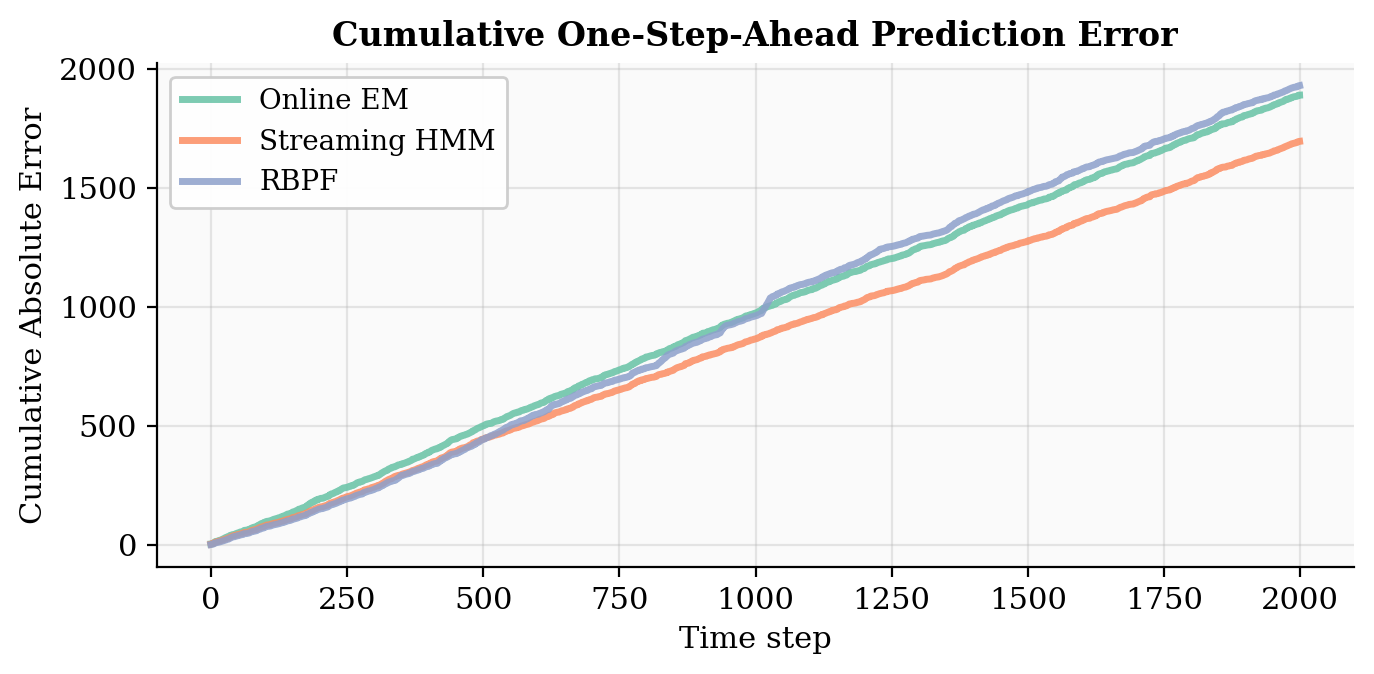

In [43]:
# Plot cumulative absolute errors
fig, ax = plt.subplots(figsize=(7, 3.5))

time_range = np.arange(n_steps)
colors_methods = sns.color_palette("Set2", len(metrics))

for m, color in zip(metrics, colors_methods):
    ax.plot(time_range, m["cumulative_error"], 
            label=m["name"], linewidth=2.5, color=color, alpha=0.85)

ax.set_xlabel("Time step", fontsize=11)
ax.set_ylabel("Cumulative Absolute Error", fontsize=11)
ax.set_title("Cumulative One-Step-Ahead Prediction Error", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_facecolor("#fafafa")

plt.tight_layout()
plt.show()


/var/folders/vf/3b13gs616172kztlr53t6_s00000gn/T/ipykernel_21797/2133854480.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names_short, rotation=15, ha='right')
/var/folders/vf/3b13gs616172kztlr53t6_s00000gn/T/ipykernel_21797/2133854480.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names_short, rotation=15, ha='right')
/var/folders/vf/3b13gs616172kztlr53t6_s00000gn/T/ipykernel_21797/2133854480.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names_short, rotation=15, ha='right')


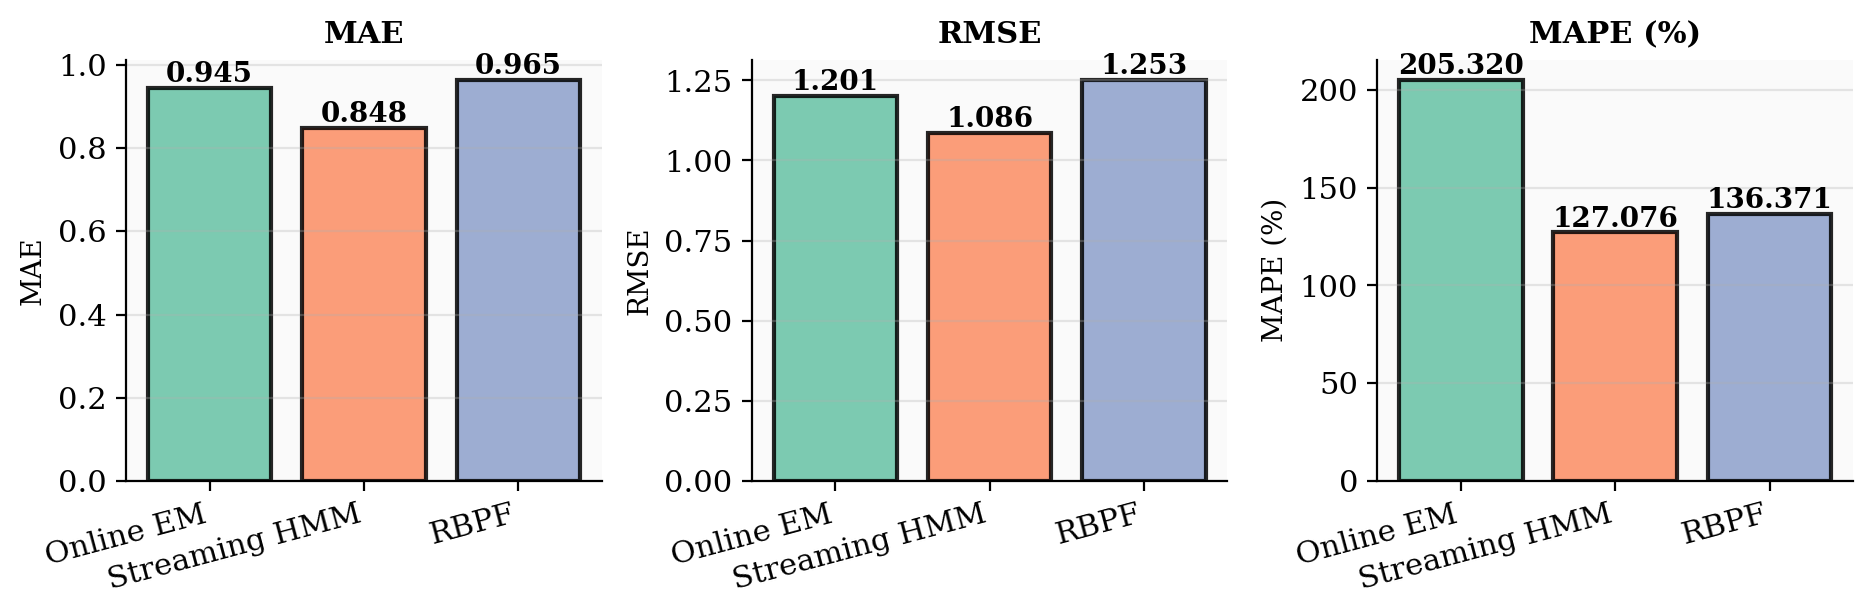


✓ All one-step-ahead predictions computed and visualized!


In [44]:
# Performance metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2))

metric_names = ["MAE", "RMSE", "MAPE (%)"]
metric_keys = ["mae", "rmse", "mape"]
method_names_short = [m["name"] for m in metrics]

for ax, metric_key, metric_name in zip(axes, metric_keys, metric_names):
    values = [m[metric_key] for m in metrics]
    bars = ax.bar(method_names_short, values, color=colors_methods, alpha=0.85, edgecolor="black", linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel(metric_name, fontsize=10)
    ax.set_title(metric_name, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor("#fafafa")
    ax.set_xticklabels(method_names_short, rotation=15, ha='right')

plt.tight_layout()
plt.show()

print("\n✓ All one-step-ahead predictions computed and visualized!")


## Section 4: Multi-Run Comparison with Error Bars

Run all three algorithms multiple times with different random seeds to evaluate robustness and compute mean ± std performance metrics and running times.



In [49]:
# Multi-run comparison: Generate new data and run all three algorithms multiple times
import pandas as pd

n_runs = 10
results = []

print(f"Running {n_runs} trials with different random seeds...")
print("=" * 70)

for run_idx in range(n_runs):
    # Generate new synthetic data for each run
    key_run = jax.random.PRNGKey(100 + run_idx)
    key_data, key_em_run, key_stream_run, key_rbpf_run = jax.random.split(key_run, 4)
    
    # Generate observations with new key
    keys_data = jax.random.split(key_data, n_steps)
    _, (true_states_run, obs_run) = jax.lax.scan(step_hmm, state_init, keys_data)
    
    # 1. Online EM
    time_start = time.time()
    mu_em, hist_means_em_run, osa_pred_em_run = online_em_gaussian_with_predictions(
        np.array(obs_run), np.array(transition_matrix), obs_var_true, alpha=alpha
    )
    time_em = time.time() - time_start
    
    errors_em_run = np.array(true_states_run) - osa_pred_em_run  # Note: using as proxy for error
    mae_em = np.mean(np.abs(np.array(obs_run) - osa_pred_em_run))
    rmse_em = np.sqrt(np.mean((np.array(obs_run) - osa_pred_em_run) ** 2))
    
    # 2. Streaming HMM
    time_start = time.time()
    bel_stream, (hist_lw_s, hist_means_s, hist_var_s, hist_forecast_s), hist_weights_s = run_streaming_hmm(
        obs_run,
        transition_matrix=transition_matrix,
        log_transition_matrix=log_transition_matrix,
        key=key_stream_run,
        n_particles=10,
        var_obs=obs_var_true,
    )
    time_streaming = time.time() - time_start
    
    osa_pred_stream = hist_forecast_s["mean"]
    mae_stream = np.mean(np.abs(np.array(obs_run) - np.array(osa_pred_stream)))
    rmse_stream = np.sqrt(np.mean((np.array(obs_run) - np.array(osa_pred_stream)) ** 2))
    
    # 3. RBPF
    time_start = time.time()
    bel_rbpf_run, (hist_lw_r, hist_means_r, hist_forecast_r, hist_ess_r), hist_weights_r = run_rbpf_streaming_hmm(
        obs_run,
        transition_matrix=transition_matrix,
        log_transition_matrix=log_transition_matrix,
        key=key_rbpf_run,
        n_particles=10,
        var_obs=obs_var_true,
        ess_threshold=0.5,
    )
    time_rbpf = time.time() - time_start
    
    osa_pred_rbpf_run = np.array(hist_forecast_r).flatten()
    mae_rbpf = np.mean(np.abs(np.array(obs_run) - osa_pred_rbpf_run))
    rmse_rbpf = np.sqrt(np.mean((np.array(obs_run) - osa_pred_rbpf_run) ** 2))
    
    # Store results
    results.append({
        'run': run_idx + 1,
        'method': 'Online EM',
        'mae': mae_em,
        'rmse': rmse_em,
        'time': time_em,
    })
    results.append({
        'run': run_idx + 1,
        'method': 'Streaming HMM',
        'mae': mae_stream,
        'rmse': rmse_stream,
        'time': time_streaming,
    })
    results.append({
        'run': run_idx + 1,
        'method': 'RBPF',
        'mae': mae_rbpf,
        'rmse': rmse_rbpf,
        'time': time_rbpf,
    })
    
    if (run_idx + 1) % 3 == 0:
        print(f"Completed {run_idx + 1}/{n_runs} runs")

print("=" * 70)
print(f"✓ Multi-run comparison complete!")

# Create DataFrame
results_df = pd.DataFrame(results)
print(f"\nResults DataFrame shape: {results_df.shape}")
print("\nFirst few rows:")
print(results_df.head(9))


Running 10 trials with different random seeds...
Completed 3/10 runs
Completed 6/10 runs
Completed 9/10 runs
✓ Multi-run comparison complete!

Results DataFrame shape: (30, 5)

First few rows:
   run         method       mae      rmse      time
0    1      Online EM  0.946360  1.203430  0.049754
1    1  Streaming HMM  0.837044  1.081409  0.105254
2    1           RBPF  0.896266  1.173358  0.396343
3    2      Online EM  0.947276  1.215420  0.045573
4    2  Streaming HMM  0.832246  1.081564  0.118790
5    2           RBPF  0.979548  1.310198  0.257801
6    3      Online EM  0.947312  1.204915  0.044768
7    3  Streaming HMM  0.830435  1.069353  0.116299
8    3           RBPF  0.917728  1.169974  0.262451


In [50]:
# Summary statistics for each method
summary = results_df.groupby('method')[['mae', 'rmse', 'time']].agg(['mean', 'std'])
print("\n" + "=" * 70)
print("MULTI-RUN PERFORMANCE SUMMARY (mean ± std over 10 runs)")
print("=" * 70)
print(summary)
print("=" * 70)

# Extract means and stds for plotting
# Define consistent method ordering to avoid pandas alphabetical sorting issues
methods_list = ['Online EM', 'Streaming HMM', 'RBPF']
mae_means = results_df.groupby('method')['mae'].mean().reindex(methods_list)
mae_stds = results_df.groupby('method')['mae'].std().reindex(methods_list)
rmse_means = results_df.groupby('method')['rmse'].mean().reindex(methods_list)
rmse_stds = results_df.groupby('method')['rmse'].std().reindex(methods_list)
time_means = results_df.groupby('method')['time'].mean().reindex(methods_list)
time_stds = results_df.groupby('method')['time'].std().reindex(methods_list)

print("\nDetailed Breakdown:")
for method in methods_list:
    method_data = results_df[results_df['method'] == method]
    print(f"\n{method}:")
    print(f"  MAE:  {method_data['mae'].mean():.4f} ± {method_data['mae'].std():.4f}")
    print(f"  RMSE: {method_data['rmse'].mean():.4f} ± {method_data['rmse'].std():.4f}")
    print(f"  Time: {method_data['time'].mean():.4f}s ± {method_data['time'].std():.4f}s")



MULTI-RUN PERFORMANCE SUMMARY (mean ± std over 10 runs)
                    mae                rmse                time          
                   mean       std      mean       std      mean       std
method                                                                   
Online EM      0.947425  0.012336  1.201888  0.017412  0.047971  0.003244
RBPF           0.966907  0.044698  1.254382  0.056845  0.287889  0.044110
Streaming HMM  0.835207  0.015747  1.074385  0.020023  0.117687  0.019702

Detailed Breakdown:

Online EM:
  MAE:  0.9474 ± 0.0123
  RMSE: 1.2019 ± 0.0174
  Time: 0.0480s ± 0.0032s

Streaming HMM:
  MAE:  0.8352 ± 0.0157
  RMSE: 1.0744 ± 0.0200
  Time: 0.1177s ± 0.0197s

RBPF:
  MAE:  0.9669 ± 0.0447
  RMSE: 1.2544 ± 0.0568
  Time: 0.2879s ± 0.0441s


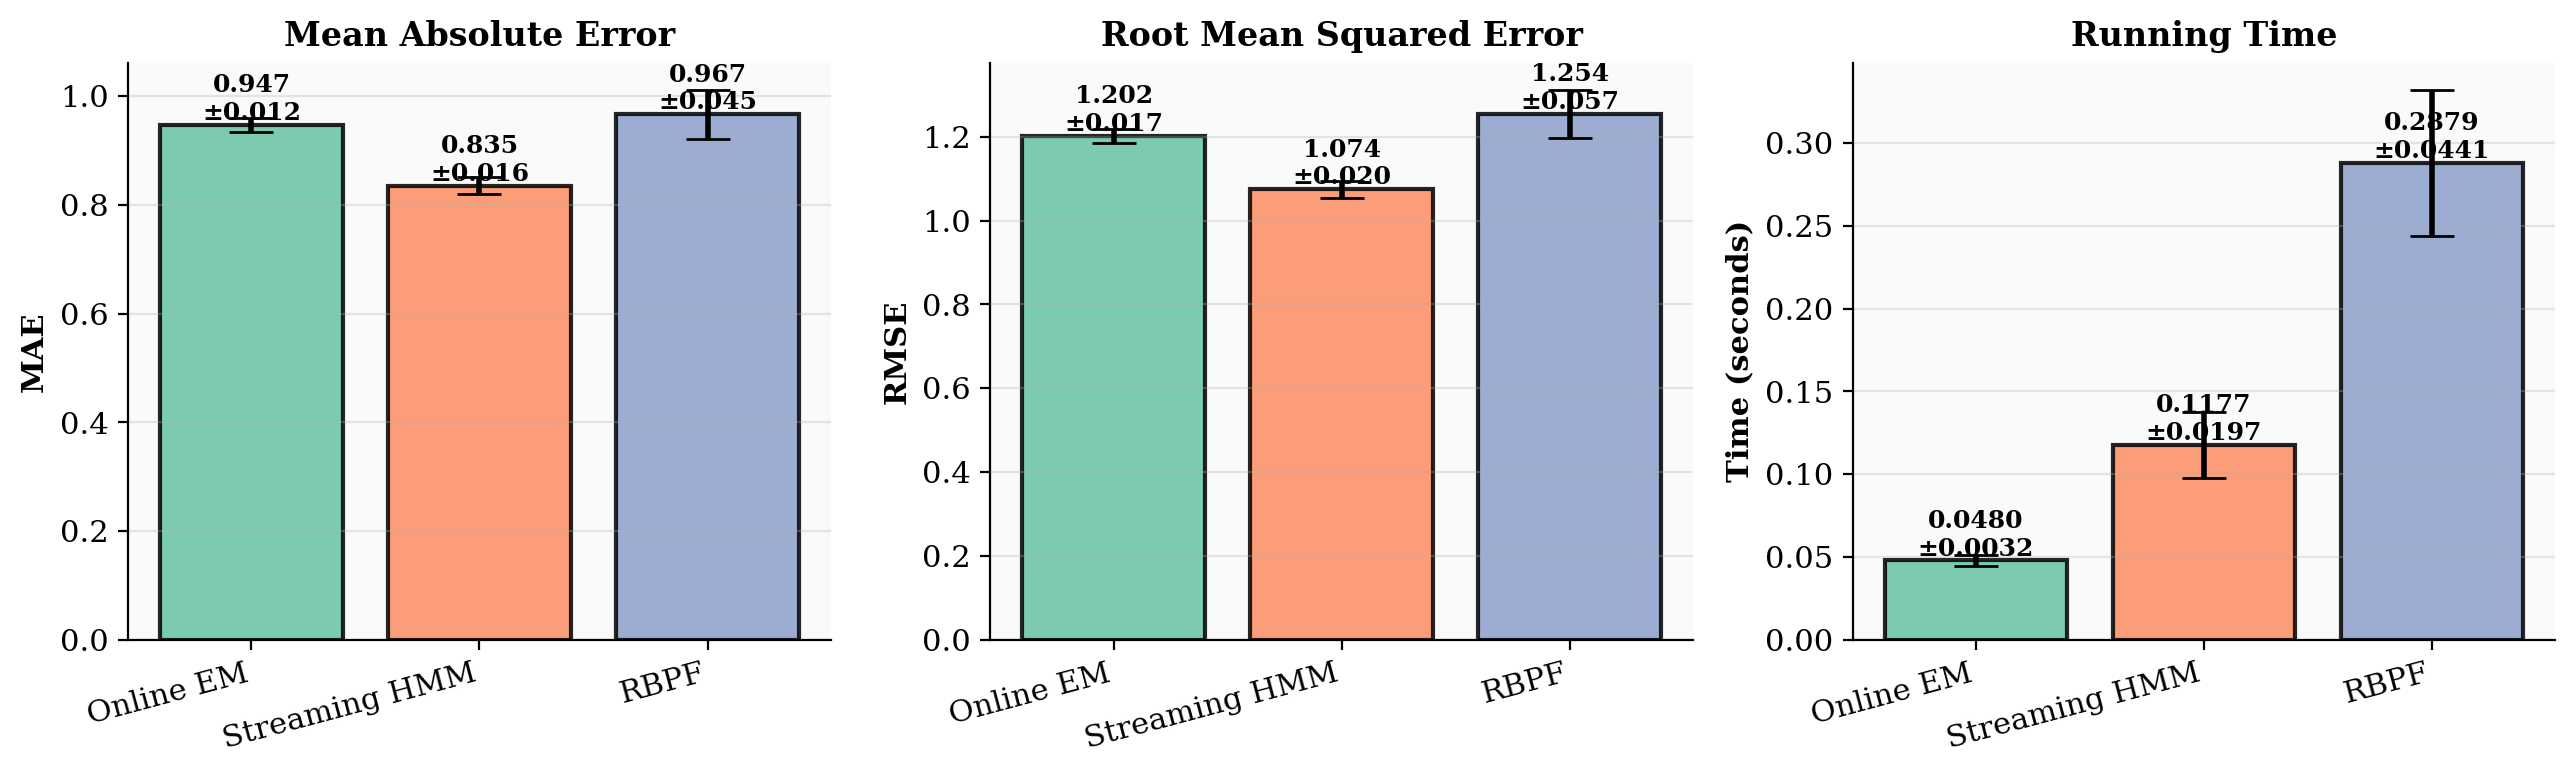


✓ Multi-run comparison visualizations complete!


In [51]:
# Visualization: Bar plots with error bars using seaborn
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Prepare x positions
x_pos = np.arange(len(methods_list))
colors_bar = sns.color_palette("Set2", len(methods_list))

# MAE Plot
ax = axes[0]
bars1 = ax.bar(x_pos, mae_means, yerr=mae_stds, capsize=8, color=colors_bar, 
               alpha=0.85, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax.set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_list, rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#fafafa")

# Add value labels on bars
for i, (bar, val, std) in enumerate(zip(bars1, mae_means, mae_stds)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE Plot
ax = axes[1]
bars2 = ax.bar(x_pos, rmse_means, yerr=rmse_stds, capsize=8, color=colors_bar,
               alpha=0.85, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax.set_title('Root Mean Squared Error', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_list, rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#fafafa")

# Add value labels on bars
for i, (bar, val, std) in enumerate(zip(bars2, rmse_means, rmse_stds)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Time Plot
ax = axes[2]
bars3 = ax.bar(x_pos, time_means, yerr=time_stds, capsize=8, color=colors_bar,
               alpha=0.85, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax.set_title('Running Time', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_list, rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#fafafa")

# Add value labels on bars
for i, (bar, val, std) in enumerate(zip(bars3, time_means, time_stds)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Multi-run comparison visualizations complete!")


/var/folders/vf/3b13gs616172kztlr53t6_s00000gn/T/ipykernel_21797/4000340888.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='method', y='mae', ax=ax, palette="Set2",
/var/folders/vf/3b13gs616172kztlr53t6_s00000gn/T/ipykernel_21797/4000340888.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
/var/folders/vf/3b13gs616172kztlr53t6_s00000gn/T/ipykernel_21797/4000340888.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='method', y='rmse', ax=ax, palette="Set2",
/var/folders/vf/3b13gs616172kztlr53t6_s

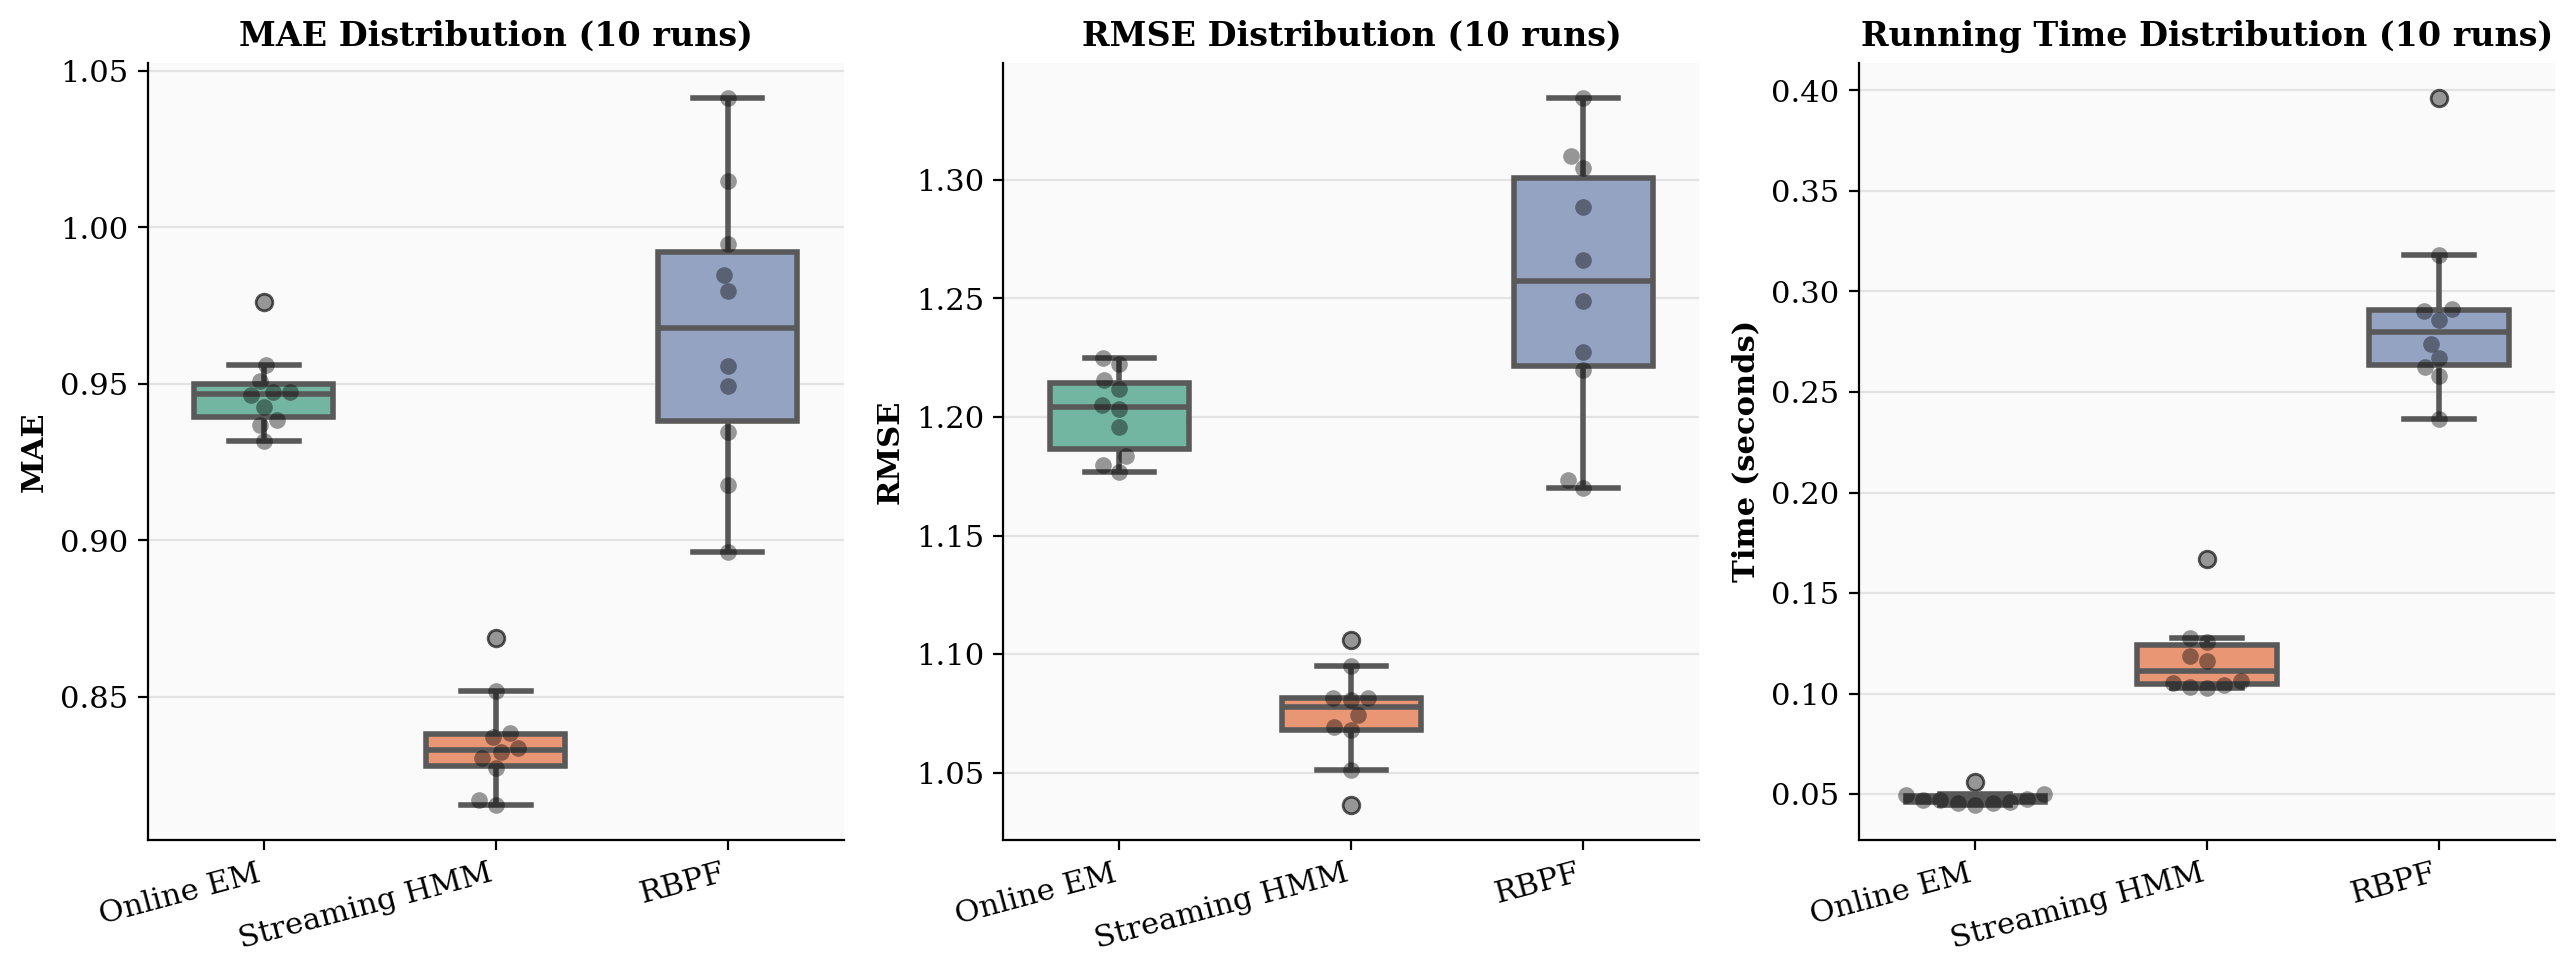

✓ Distribution plots complete!


In [52]:
# Box plots with seaborn showing full distribution across runs
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# MAE Box Plot
ax = axes[0]
sns.boxplot(data=results_df, x='method', y='mae', ax=ax, palette="Set2", 
            width=0.6, linewidth=2)
sns.swarmplot(data=results_df, x='method', y='mae', ax=ax, color='black', 
              alpha=0.4, size=6)
ax.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_title('MAE Distribution (10 runs)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#fafafa")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

# RMSE Box Plot
ax = axes[1]
sns.boxplot(data=results_df, x='method', y='rmse', ax=ax, palette="Set2",
            width=0.6, linewidth=2)
sns.swarmplot(data=results_df, x='method', y='rmse', ax=ax, color='black',
              alpha=0.4, size=6)
ax.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_title('RMSE Distribution (10 runs)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#fafafa")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

# Time Box Plot
ax = axes[2]
sns.boxplot(data=results_df, x='method', y='time', ax=ax, palette="Set2",
            width=0.6, linewidth=2)
sns.swarmplot(data=results_df, x='method', y='time', ax=ax, color='black',
              alpha=0.4, size=6)
ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_title('Running Time Distribution (10 runs)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#fafafa")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

print("✓ Distribution plots complete!")
